(sec:modello-uniforme-continuo)=
# Il modello uniforme continuo

Dati $a, b \in \mathbb R$, con $a < b$, definiamo $Y = a + X (b-a)$, dove $X$
è la variabile aleatoria introdotta nel
{numref}`Paragrafo %s <sec:dal-discreto-al-continuo>`. Si verifica facilmente
che $Y$ è una variabile aleatoria avente come supporto $D_Y = [a, b]$, dunque
una variabile aleatoria continua. Se si considera poi un generico
$y \in (a, b)$, si ha

\begin{align}
F_Y(y) &= \mathbb P(Y \leq y) = \mathbb P(a + X (b-a) \leq y) \\
       &= \mathbb P \left( X \leq \frac{y - a}{b - a} \right)
        = \frac{y - a}{b - a} \enspace,
\end{align}

mentre $\forall y < a \; \mathbb P(Y \leq y) = 0$ e
$\forall y > b \; \mathbb P(Y \leq y) = 1$, e dunque riunendo i vari casi si
ottiene

```{math}
F_Y(y) =  \frac{y - a}{b - a} \; \mathrm I_{[a, b]}(y)
          + \mathrm I_{(b + \infty)}(y) \enspace.
```

Analogamente, per $y \in (a, b)$

```{math}
f_Y(y) = F_Y'(y) = \frac{1}{b - a} \enspace.
```

D'altra parte, quando $y < a$ o $y > b$ ci si trova al di fuori del dominio
della variabile aleatoria, pertanto $f_Y(y) = 0$. Riassumendo, la densità di
$Y$ è tale che

```{math}
f_Y(y) = \frac{1}{b - a} \; \mathrm I_{[a, b]}(y) \enspace.
```

Per ogni $a < b$ abbiamo quindi definito una variabile aleatoria
continua la cui densità è costante nel corrispondente intervallo $[a, b]$.
Coerentemente con il {numref}`sec:dal-discreto-al-continuo`, ci riferiremo
a essa come alla _distribuzione uniforme continua_ sull'intervallo $[a, b]$.

````{prf:definition} La distribuzione uniforme continua
:label: def:uniform-continuous
Dati $a, b \in \mathbb R$ con $a < b$, la _distribuzione uniforme continua_
su $[a, b]$ è definita dalla densità

```{math}
f(x) =  \frac{1}{b - a} \; \mathrm I_{[a, b]}(x) \enspace,
```

o in modo equivalente dalla ripartizione

```{math}
F(x) =  \frac{y - a}{b - a} \; \mathrm I_{[a, b]}(x)
          + \mathrm I_{(b + \infty)}(x) \enspace.
```

Indicheremo il fatto che una variabile aleatoria $X$ segue una distribuzione
uniforme continua sull'intervallo $[a, b]$ utilizzando la notazione
$X \sim \mathrm U([a, b])$, con ovvie estensioni per il caso di intervalli
non chiusi. Per brevità, diremo a volte che $X$ è una variabile aleatoria
uniforme continua su $[a, b]$.
````

```{margin}
Ho scelto questo esempio per sottolineare che non tutte le distribuzioni
sono definite su supporti che contengono solo numeri non negativi.
```
La {numref}`Figura %s <fig:uniform-continuous>` mostra il grafico delle
funzioni di densità e di ripartizione per la distribuzione uniforme continua
su $[-1, 1]$.

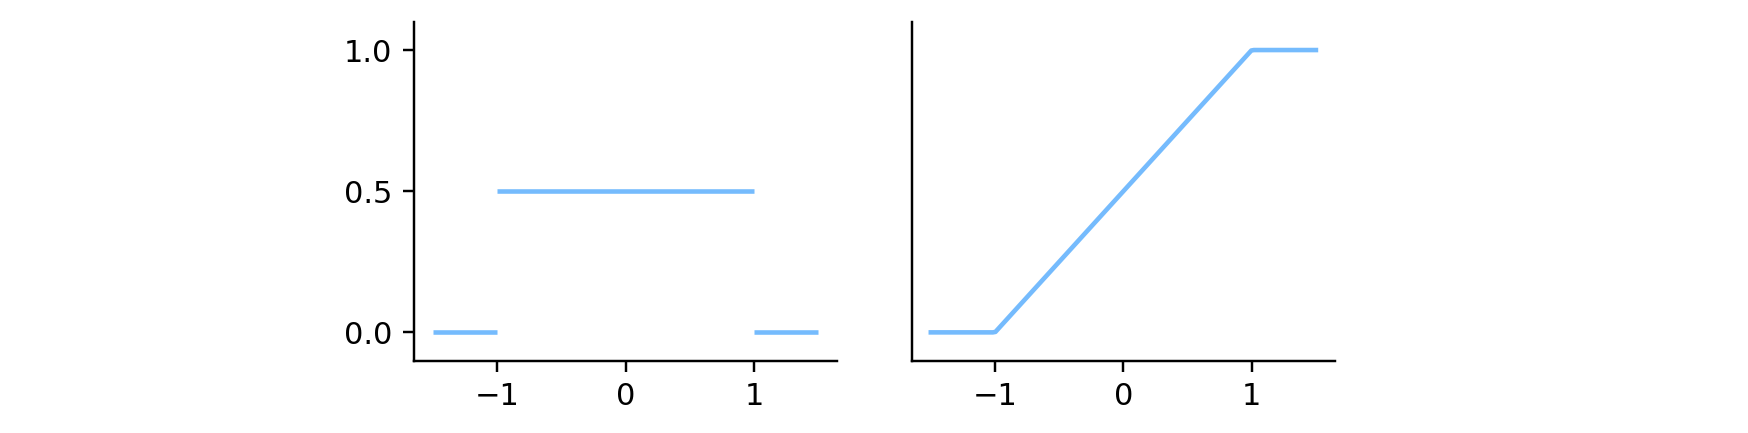

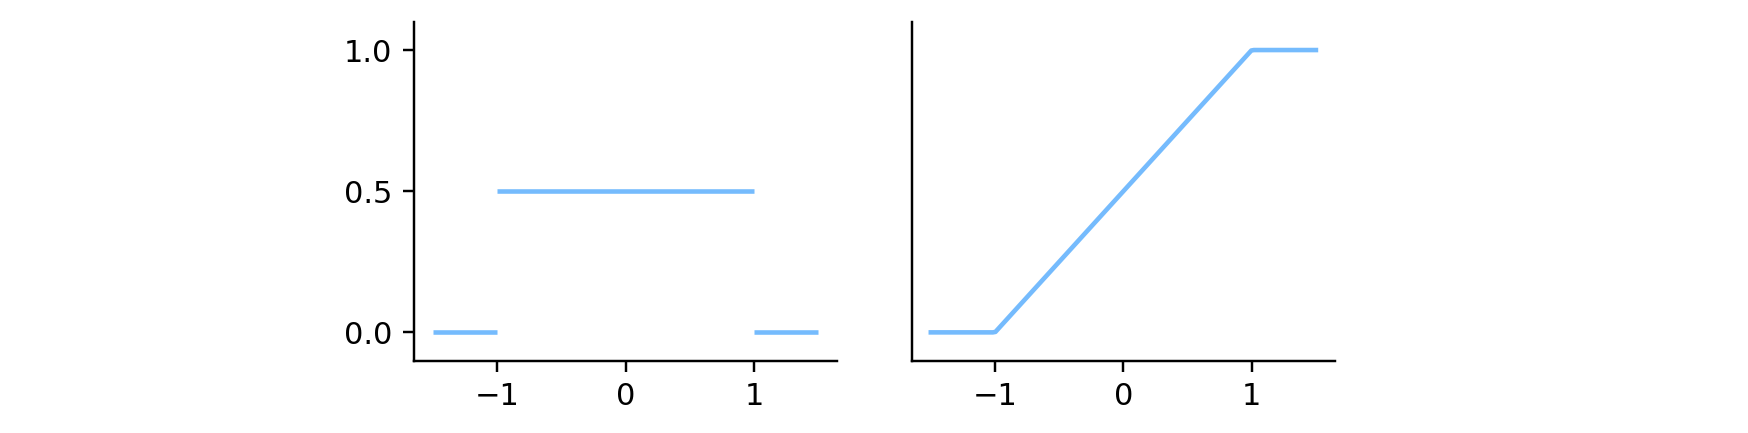

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from myst_nb import glue

def uniform_pdf(a, b, x):
    return np.where((a <= x) & (x <= b),  1 / (b - a), 0)

def uniform_cdf(a, b, x):
    return np.where((a <= x) & (x <= b), (x - a) / (b - a),
                    np.where(x < a, 0, 1))

plt.style.use('sds.mplstyle')

fig, axes = plt.subplots(1, 4,
                         gridspec_kw={'width_ratios': [.15, .2, .2, .15]},
                         figsize=(10, 2))

x = np.linspace(-1.5, 1.5, 150)
y_pdf = uniform_pdf(-1, 1, x)
y_cdf = uniform_cdf(-1, 1, x)

axes[1].hlines([0, 0.5, 0], [-1.5, -1, 1], [-1, 1, 1.5])
axes[2].plot(x, y_cdf)

axes[1].set_yticks([0, 0.5, 1])
axes[2].set_yticks([])
for a in axes[1:3]:
  a.set_ylim(-0.1, 1.1)

axes[0].axis('off')
axes[3].axis('off')

glue("uniform-continuous", fig, display=True)

```{glue:figure} uniform-continuous
:name: fig:uniform-continuous

I grafici della funzione di densità (a sinistra) e della funzione di
ripartizione (a destra) della distribuzione uniforme continua sull'intervallo
$[-1, 1]$.
```

Va notato come la distribuzione derivata nel
{numref}`Paragrafo %s <sec:dal-discreto-al-continuo>` rappresenti la
distribuzione uniforme continua per il caso $a=0$ e $b=1$, e come in generale
il procedimento seguito per ottenere la distribuzione uniforme continua non
porta a un risultato diverso nel caso in cui il supporto da cui si parte sia
un intervallo aperto o semiaperto. Per brevità, uniamo quindi tutte le
distribuzioni uniformi continue su un intervallo nella famiglia definita di
seguito.

```{margin}
Nonostante sia possibile definire una distribuzione uniforme su un insieme
continuo che non sia un intervallo, per brevità si utilizza la dicitura
_uniforme continua_ per riferirsi alle sole distribuzioni che hanno un
intervallo come supporto.
```
````{prf:definition} La famiglia uniforme continua
:label: def:continuous-uniform-family
La _famiglia uniforme continua_ comprende tutte le definizioni uniformi
continue definite su un intervallo in $\mathbb R$, indipdententemente dalla
particolare forma di questo intervallo.
````

## Media e varianza

Media, varianza e deviazione standard di una generica distribuzione
uniforme continua si ottengono facilmente a partire dalle definizioni
corrispondenti.

````{prf:lemma}
Dati $a, b \in \mathbb R$ con $a < b$, sia $X \sim \mathrm U([a, b])$. Si ha

```{math}
:label: eq:uniform-continuous
\mathbb E(X) = \frac{a + b}{2}
\quad \text{e} \quad
\mathrm{Var}(X) = \frac{(b - a)^2}{12} \enspace.
```
```{prf:proof}
Il valore atteso si calcola sfruttando il prodotto notevole legato alla
differenza di quadrati:

\begin{align*}
\mathbb E(X) &= \int_{-\infty}^{+\infty} x f_X(x; a, b) \;\mathrm d x
              = \int_a^b \frac{x}{b - a} \;\mathrm d x \\
             &= \frac{1}{b-a} \frac{x^2}{2} \bigg|_a^b
              = \frac{b^2 - a^2}{2(b - a)} = \frac{a + b}{2} \enspace.
\end{align*}

Analogamente, la formula relativa alla differenza di cubi permette di
calcolare $\mathbb E(X^2)$:

\begin{align*}
\mathbb E(X^2) &= \int_{-\infty}^{+\infty} x^2 f_X(x; a, b) \;\mathrm d x
              = \int_a^b \frac{x^2}{b - a} \;\mathrm d x \\
             &= \frac{1}{b-a} \frac{x^3}{3} \bigg|_a^b
              = \frac{b^3 - a^3}{3(b - a)}
              = \frac{b^2 + a b + a^2}{3} \enspace,
\end{align*}

così che $\mathrm{Var}(X) = \frac{b^2 + a b + a^2}{3} -
                            \frac{b^2 - 2 a b + a^2}{4}
                          = \frac{b^2 - a^2}{12}$.
```
````

Si può notare che considerando $X \sim \mathrm U([0, 1])$ e
$Y \coloneqq a + (b - a) X \sim \mathrm U([a, b])$, come indicato all'inizio di
questo paragrafo, le proprietà di valore atteso e varianza permettono di
ottenere in modo alternativo gli stessi risultati partendo da quanto ottenuto
nel {numref}`Paragrafo %s <sec:dal-discreto-al-continuo>` per la distribuzione
uniforme continua in $[0, 1]$: precisamente,
$\mathbb E(Y) = a + (b - a) \mathbb E(X) = a + \frac{b - a}{2}
= \frac{a + b}{2}$ e $\mathrm{Var}(Y) = (b - a)^2
\mathrm{Var}(X) = \frac{(b - a)^2)}{12}$. Inoltre sostituendo $a=0$ e $b=1$
in {eq}`eq:uniform-continuous` si ottengono la media e la varianza della
distribuzione uniforme continua in $[0, 1]$.

## Momenti della distribuzione uniforme continua (*)

La funzione generatrice dei momenti per la distribuzione uniforme continua
si calcola facilmente, vista la semplice forma analitica della relativa
funzione di densità di probabilità. Infatti, data $X \sim \mathrm U([a, b])$,
se $t \neq 0$

```{math}
:label: eq:mgf-uniform
m_X(t) = \mathbb E \left( \mathrm e^{tX} \right)
       = \int_a^b \frac{\mathrm e^{tx}}{b - a} \mathrm d x
       = \frac{1}{t(b - a)} \int_a^b t \mathrm e^{tx} \mathrm d x
       = \frac{1}{t(b - a)} \int_{ta}^{tb} \mathrm e^y \mathrm d y
        = \frac{\mathrm e^{tb} - \mathrm e^{ta}}{t(b - a)} \enspace,
```

e $m_X(0) = \mathbb E ( 1 ) = 1$ altrimenti.

La derivata prima di questa funzione generatrice dei momenti è

```{math}
m'_X(t) = \frac{\mathrm e^{tb}(tb - 1) - \mathrm e^{ta}(ta - 1)}{t^2 (b - a)}
          \enspace,
```

```{margin}
I conti da fare sono un po' lunghi, in quanto è necessario utilizzare due
volte la regola di de l'Hôpital e calcolare derivate di prodotti, ma
assolutamente non difficili.
```
anche in questo caso, per $t = 0$ la funzione non risulta definita, ma è
possibile calcolare il suo limite per $t \to 0$, ottenendo

```{math}
\lim_{t \to 0} m'_X(t) = \frac{a + b}{2} \enspace,
```

che coincide, come deve essere, con il valore atteso della distribuzione.
A partire dalla funzione generatrice dei momenti è possibile calcolare i
momenti centrali, ma il procedimento risulta più complesso rispetto al diretto
utilizzo della relativa definizione. Per alleggerire la notazione, poniamo
$\mu = \mathbb E(X) = \frac{a + b}{2}$, così che il momento centrale $n$-esimo
è uguale a

\begin{align*}
\mu_n &= \mathbb E \left( (X - \mu)^n \right)
       = \int_a^b \frac{1}{b - a} \left( x - \mu \right)^n \;\mathrm dx
       = \frac{1}{b - a} \int_{a-\mu}^{b-\mu} y^n \;\mathrm dy
       = \frac{1}{b - a} \left. \frac{y^{n+1}}{n+1} \right|_{a-\mu}^{b-\mu} \\
      &= \frac{(b - \mu)^{n+1} - (a - \mu)^{n+1}}{(n + 1)(b - a)} \enspace.
\end{align*}

Tenuto conto del fatto che $a - \mu = \frac{a - b}{2}$ e analogamente
$b - \mu = \frac{b - a}{2}$, si ha dunque

```{math}
\mu_n = \frac{\left( \frac{b - a}{2} \right)^{n+1} -
        \left( \frac{a - b}{2} \right)^{n+1}}{(n + 1)(b - a)}
      = \frac{(b - a)^{n+1} - (a - b)^{n+1}}{(n + 1) 2^{n+1}(b - a)}
      = \frac{(b - a)^{n+1} + (-1)^n (b - a)^{n+1}}{(n + 1) 2^{n+1}(b - a)}
        \enspace.
```

Pertanto, quando $n$ è dispari si annulla sempre il numeratore della
frazione, e dunque $\mu_n = 0$, mentre per $n$ pari si ha

```{math}
\mu_n = \frac{2(b - a)^{n+1}}{(n + 1) 2^{n+1}(b - a)}
      = \frac{(b - a)^n}{(n + 1) 2^n} \enspace.
```

Da questo risultato si ottiene che, per una generica distribuzione uniforme
continua tra $a$ e $b$

- la varianza è uguale a $\mu_2 = \frac{(b - a)^2}{3 \cdot 4}$, come già
  abbiamo ricavato;
- annullandosi il terzo momento centrale, la skewness vale zero, cosa peraltro
  facilmente evincibile osservando che la densità di probabilità è simmetrica
  rispetto al valore atteso;
- la curtosi è uguale a

  ```{math}
  \frac{\mu_4}{\sigma^4} - 3 = \frac{(b - a)^4}{5 \cdot 16}
                               \frac{144}{(b - a)^4} - 3
                             = \frac{9}{5} - 3 = - \frac{6}{5} \enspace,
  ```

  il che significa che questa distribuzione è _platicurtica_, nel senso che
  è più piatta rispetto a una distribuzione normale che ha lo stesso valore
  atteso e la stessa varianza, come illustrato nella
  {numref}`Figura %s <fig:uniform-kurtosis>`.

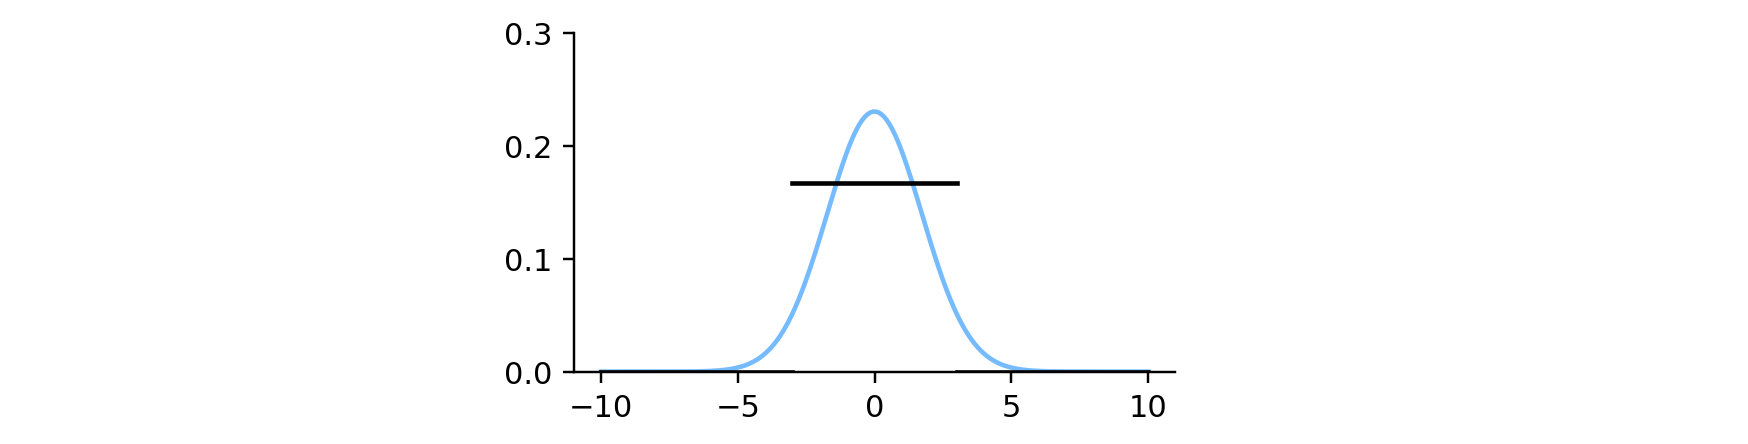

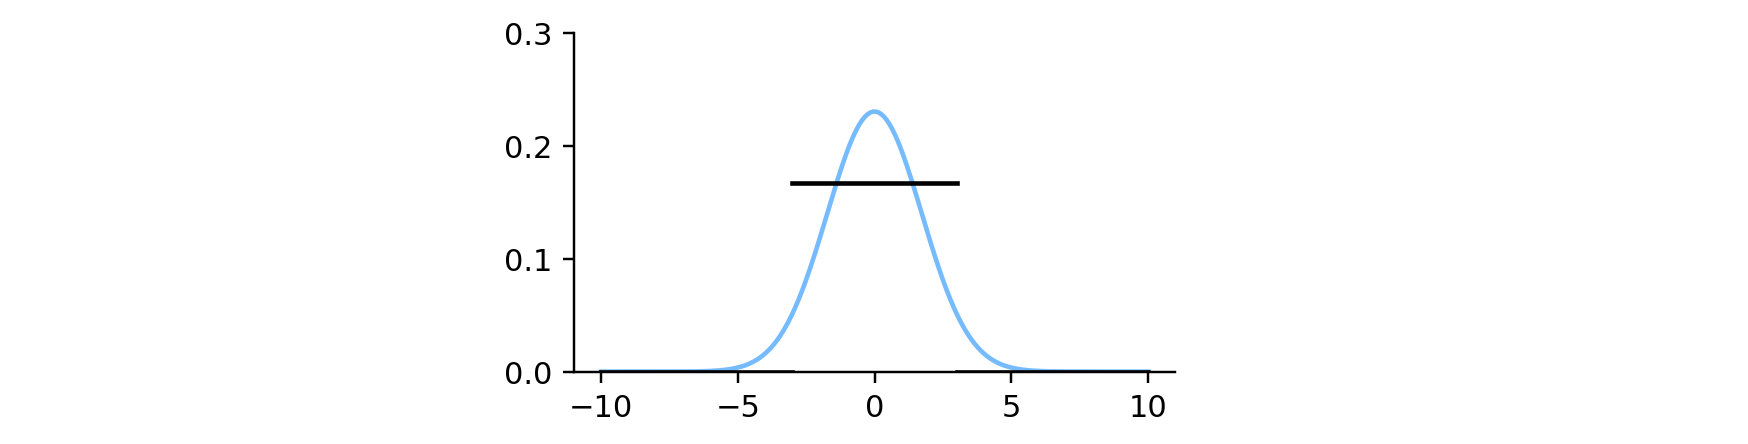

In [2]:
from scipy import stats as st
plt.style.use('sds.mplstyle')

a = -3
b = 3

fig, (ax_l, ax, ax_r) = plt.subplots(1, 3,
                              gridspec_kw={'width_ratios': [.15, .2, .15]},
                              figsize=(10, 2))

ax_l.axis('off')
ax_r.axis('off')

x = np.linspace(-10, 10, 200)
Z = st.norm((a+b)/2, (b-a)/(12)**0.5)
y_norm = Z.pdf(x)

ax.plot(x, y_norm)

ax.plot([-10, a], [0, 0], c='k')
ax.plot([a, b], [1/(b-a), 1/(b-a)], c='k')
ax.plot([b, 10], [0, 0], c='k')
ax.set_ylim(0, 0.3)
fig.show()

glue("uniform-kurtosis", fig, display=True)

```{glue:figure} uniform-kurtosis
---
name: fig:uniform-kurtosis
---
Grafici delle funzioni di densità di probabilità di due distribuzioni,
rispettivamente uniforme continua tra -3 e 3 (spezzata nera) e normale avente
lo stesso valore atteso e la stessa varianza di quella uniforme (curva blu).
Il secondo grafico evidenzia un picco più alto rispetto al primo, essendo
l'uniforme continua una distribuzione platicurtica.
```


## Quantili della distribuzione uniforme continua (*)

```{margin}
Per non complicare la trattazione, ho fatto qui riferimento a intervalli
chiusi, ma il ragionamento descritto vale per qualsiasi tipo di intervalli.
```
Tenuto conto del fatto che la densità di una distribuzione uniforme
continua è costante su un intervallo $I = [a, b]$ e nulla altrove,
intuitivamente il relativo quantile di livello $q \in [0, 1]$ sarà il punto di
$I$ caratterizzato dalle seguenti proprietà:
- la sua distanza da $a$ cresce linearmente rispetto a $q$,
- la sua distanza da $b$ cresce linearmente rispetto a $1-q$.

Più formalmente, $x_q$ sarà uguale alla _combinazione lineare convessa_ di
$a$ e $b$ che ha $q$ come coefficiente:

```{math}
x_q = a + q (b - a) \enspace,
```
come dimostrato qui di seguito.

````{prf:lemma}
Dati $a, b \in \mathbb R$ con $a < b$, una variabile aleatoria
$X \sim \mathrm U([a, b])$ e $q \in [0, 1]$, il quantile di livello $q$ di
$X$ è $x_q = a + q (b - a)$.
```{prf:proof}
La tesi è banale quando $q=0$ perché in questo caso il quantile è la più
piccola specificazione di $X$ e dunque $x_0 = a = a + 0 (b - a)$. Un
ragionamento analogo vale nel caso $q =1 $. Concentriamoci dunque sul caso
$q \in (0, 1)$ e consideraimo l'equazione $F_X(x_q) = q$, che definisce il
quantile cercato e che equivale a

\begin{equation*}
\frac{x - a}{b - a} = q \enspace.
\end{equation*}

La sua soluzione è $x_q = a + q (b - a)$.
```
````

Da questo lemma si ricava immediatamente che, per una distribuzione
uniforme continua tra $a$ e $b$,

- la mediana coincide con la media, cosa peraltro implicata dal fatto che la
  densità di probabilità è simmetrica rispetto al valore atteso;
- il primo e il terzo quartile sono rispettivamente
  $\frac{3a + b}{4}$ e $\frac{a + 3b}{4}$; 
- il range interquartile vale $\frac{a+b}{2}$.

La {numref}`Figura %s <fig:uniform-continuous-bp>` evidenzia che, come era
pienamente ragionevole aspettarsi tenendo conto della forma della funzione di
densità di probabilità, il diagramma a scatola per questa distribuzione, è
perfettamente simmetrico.

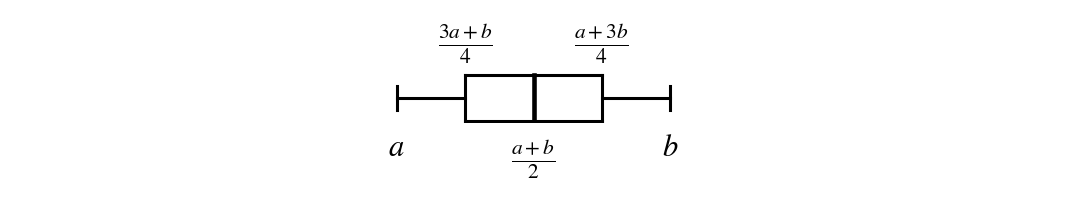

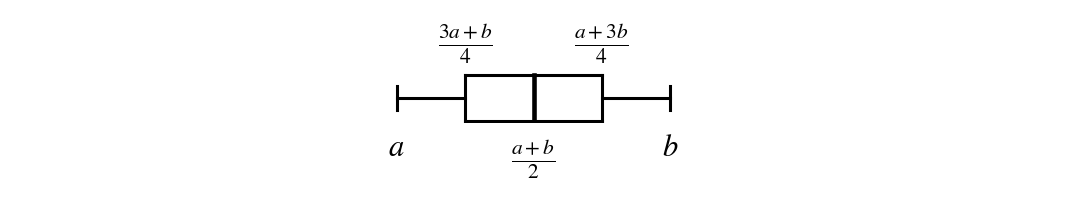

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(6, 0.3))

for ax in axes:
  ax.axis('off')

ax = axes[1]

a = -3
b = 5

first_quartile = (3*a + b) / 4
median = (a + b) / 2
third_quartile = (a + 3*b) / 4

lw = 1
height = 0.2

ax.plot([median, median], [-height, height], c='k', linewidth=1.5)

ax.plot([a, a], [-.1, .1], c='k', linewidth=lw)
ax.plot([a, first_quartile], [0, 0], c='k', linewidth=lw)

ax.plot([first_quartile, first_quartile], [-height, height],
         c='k', linewidth=lw)

ax.plot([third_quartile, third_quartile], [-height, height],
         c='k', linewidth=lw)

ax.plot([first_quartile, third_quartile], [height, height],
         c='k', linewidth=lw)
ax.plot([first_quartile, third_quartile], [-height, -height],
         c='k', linewidth=lw)

ax.plot([third_quartile, b], [0, 0], c='k', linewidth=lw)
ax.plot([b, b], [-.1, .1], c='k', linewidth=lw)

ax.text(a, -0.5, '$a$', ha='center')
ax.text(b, -0.5, '$b$', ha='center')
ax.text(median, -0.6, r'$\frac{a+b}{2}$', ha='center')

ax.text(first_quartile, 0.4, r'$\frac{3a + b}{4}$', ha='center')
ax.text(third_quartile, 0.4, r'$\frac{a + 3b}{4}$', ha='center')

fig.show()

glue("uniform-continuous-bp", fig)

```{glue:figure} uniform-continuous-bp
:name: fig:uniform-continuous-bp
:figwidth: 100%

Diagramma a scatola per la distribuzione uniforme continua tra $a$ e $b$.
```

## Implementazione del modello uniforme continuo

Per quanto rigaurda le distribuzioni discrete, `scipy.stats` mette
a disposizione delle funzioni con un'interfaccia _naturale_ i cui parametri
sono direttamente legati ai parametri della distribuzione stessa. Anche nel
caso continuo, ogni distribuzione è associata a una funzione che restituisce
le istanze delle corrispondenti classi. Però, indipendentemente dalla
distribuzione che si vuole generare, queste funzioni si invocano specifcando
sempre i parametri `loc` e `scale`, legati rispettivamente alla centralità e
alla dispersione della distribuzione generata. La relazione precisa
tra i valori specificati per questi argomenti e il risultato ottenuto cambia
di caso in caso. Per quanto riguarda una generica distribuzione uniforme
continua $\mathrm U([a, b])$, il valore di `loc` coincide con $a$, mentre
quello di `scale` equivale a $b - a$. La
{numref}`Figura %s <fig:uniform-implementation>` mostra l'istogramma che si
ottiene a partire da un campione di valori pseudo-casuali generati da questa
implementazione, sovrapposto al grafico della corrisondente funzione di
densità di probabilità.

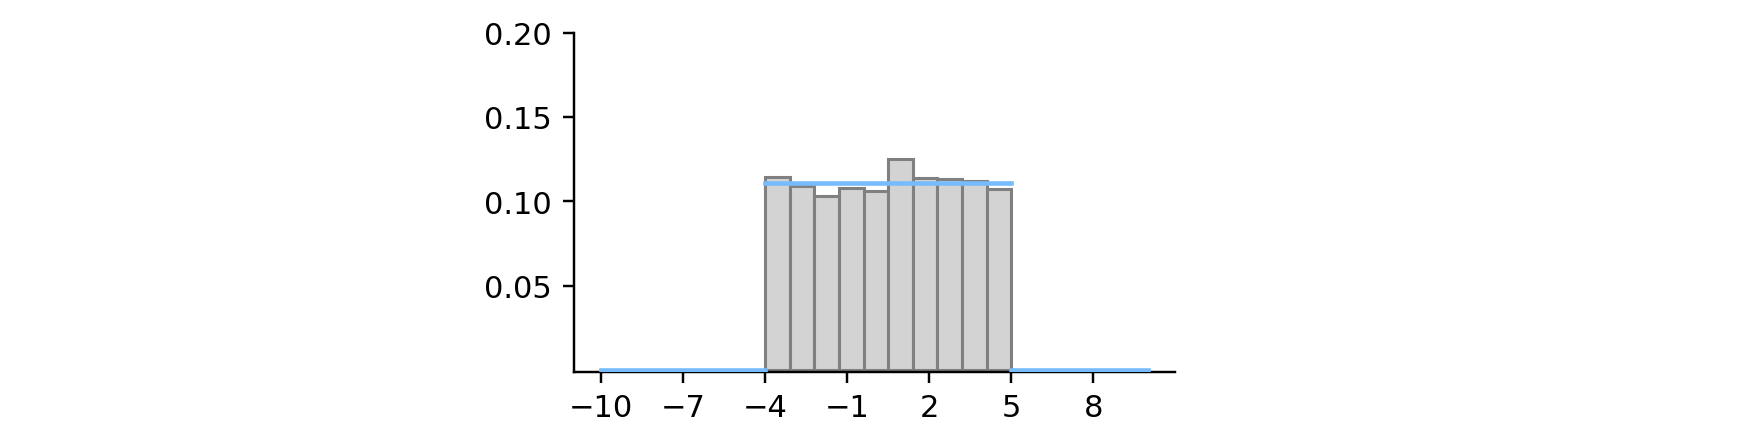

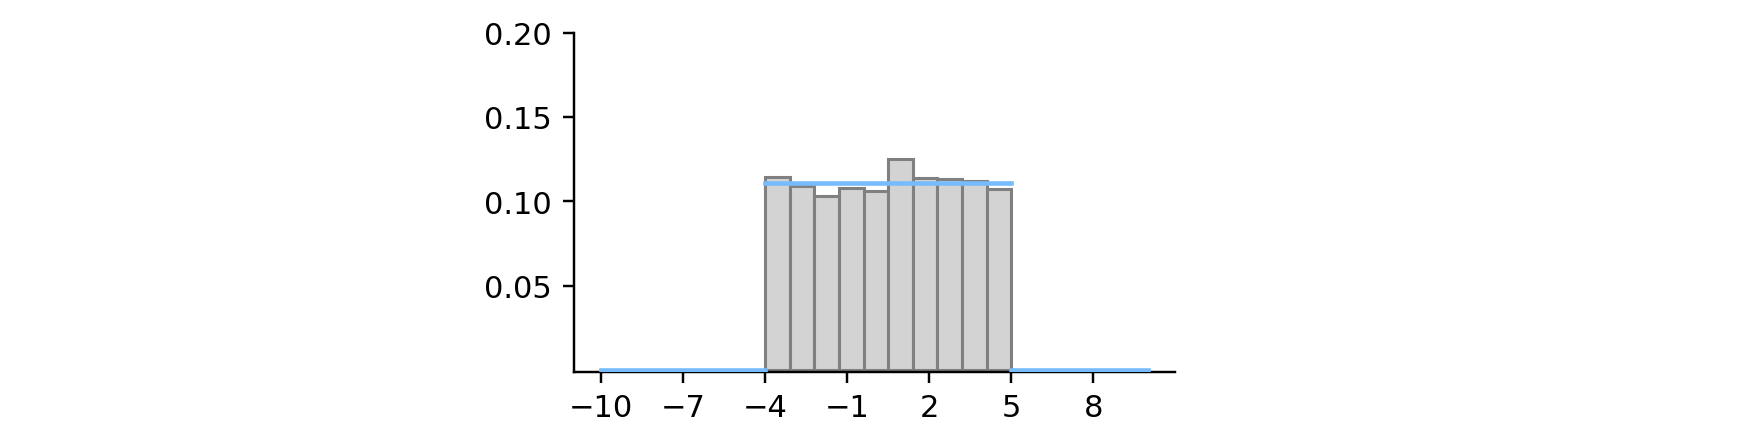

In [4]:
fig, (ax_l, ax, ax_r) = plt.subplots(1, 3,
                              gridspec_kw={'width_ratios': [.15, .2, .15]},
                              figsize=(10, 2))

ax_l.axis('off')
ax_r.axis('off')

a = -4
b = 5

U = st.uniform(a, b-a)

m = 5000
x = U.rvs(m)

ax.hist(x, bins=10, density=True, color='lightgray', edgecolor='gray')

ax.plot([-10, a], [0, 0], c='C0', zorder=3)
ax.plot([a, b], [1/(b-a), 1/(b-a)], c='C0')
ax.plot([b, 10], [0, 0], c='C0', zorder=3)
ax.set_ylim(-.001, .2)
ax.set_xticks([-10, -7, -4, -1, 2, 5, 8])
ax.set_yticks([.05, .1, .15, .2])
fig.show()

glue("uniform-implementation", fig)

```{glue:figure} uniform-implementation
:name: fig:uniform-implementation
:figwidth: 100%

Le barre mostrano l'istogramma ottenuto a partire da un insieme di valori
pseudo-casuali generati a partire da una distribuzione uniforme tra $-4$ e
$5$, mentre le spezzate corrispondono al grafico della funzione di densità di
probabilità della medesima distribuzione.
```